# Muziekclassificatie — Drempelwaarde-model

**Project R.E.M. · ML-notebook**

Classificeert nummers uit de Spotify-bibliotheek van deelnemers als **CALM**, **ENERGY** of **OTHER**
op basis van een gewogen arousal-score berekend uit audio-kenmerken.

**Aanpak:**
1. Voorfilter — verwijder live-opnames en gesproken-woord tracks
2. Normalisatie — MinMaxScaler per deelnemer
3. Arousal-score — gewogen som van audio-kenmerken
4. Classificatie — drempelwaarden op de arousal-score

**Artefacten:** `models/music_classification/{codename}_scaler.pkl` · `models/music_classification/{codename}_config.json`  
**Uitvoer:** `data/analysis/{codename}/classified_songs.csv`

In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [2]:
# ── Configuratie ─────────────────────────────────────────────────────────────
# REUSE_MODEL = True  → laad bestaande scaler + config vanuit models/music_classification/
# REUSE_MODEL = False → fit nieuwe scaler en sla op
REUSE_MODEL = False

# PARTICIPANT: "all" → alle deelnemers automatisch detecteren
#              string → bijv. "peer"
PARTICIPANT = "all"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paden ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent.parent
PLAYLISTS_DIR = PROJECT_ROOT / "data" / "playlists"
ANALYSIS_DIR  = PROJECT_ROOT / "data" / "analysis"
MODELS_DIR    = PROJECT_ROOT / "models" / "music_classification"

# ── Audio-kenmerken ───────────────────────────────────────────────────────────
SCORING_FEATURES = [
    "tempo", "energy", "loudness", "valence",
    "danceability", "acousticness", "instrumentalness", "speechiness",
]

# ── Gewichten voor arousal-score ──────────────────────────────────────────────
# Positief = verhoogt arousal, negatief = verlaagt arousal
AROUSAL_WEIGHTS = {
    "energy":       0.35,
    "tempo":        0.30,
    "loudness":     0.20,
    "acousticness": -0.10,
    "danceability": 0.05,
}

# ── Voorfilter-drempels (Spotify-documentatie) ────────────────────────────────
SPEECHINESS_MAX = 0.66   # > 0.66 = gesproken woord / podcast
LIVENESS_MAX    = 0.80   # > 0.80 = hoge kans op live-opname

# ── Classificatiedrempels ─────────────────────────────────────────────────────
CALM_THRESHOLD   = 0.35
ENERGY_THRESHOLD = 0.65
VALENCE_FLOOR    = 0.25  # CALM-nummers moeten positief genoeg zijn (geen droef muziek)

# ── Visuele stijl (donker thema) ──────────────────────────────────────────────
DARK = {
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#e2e8f0",
    "ytick.color":      "#e2e8f0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
}
plt.rcParams.update(DARK)
plt.rcParams["figure.dpi"] = 120

# Okabe-Ito kleuren per klasse
CLASS_COLORS = {"calm": "#56b4e9", "energy": "#e69f00", "other": "#999999"}

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"REUSE_MODEL  : {REUSE_MODEL}")
print(f"PARTICIPANT  : {PARTICIPANT}")

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project
REUSE_MODEL  : False
PARTICIPANT  : all


---
## 1. Data laden

In [3]:
def load_combined(codename: str) -> pd.DataFrame:
    """Laad combined.csv voor één deelnemer."""
    path = PLAYLISTS_DIR / codename / "playlists_generated" / "combined.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Invoerbestand niet gevonden voor '{codename}'.\n"
            f"Verwacht: {path}\n"
            f"Zorg dat de playlist-pipeline is uitgevoerd: "
            f"uv run python scripts/playlists/spotify_cli.py prepare {codename}"
        )
    df = pd.read_csv(path)
    df["participant"] = codename
    return df


def detect_participants() -> list[str]:
    """Detecteer alle deelnemers met een combined.csv."""
    return sorted(
        d.name for d in PLAYLISTS_DIR.iterdir()
        if d.is_dir() and (d / "playlists_generated" / "combined.csv").exists()
    )


# Bepaal welke deelnemers we verwerken
if PARTICIPANT == "all":
    participants = detect_participants()
    if not participants:
        raise FileNotFoundError(
            f"Geen combined.csv gevonden onder {PLAYLISTS_DIR}.\n"
            "Verwerk eerst de playlists met de spotify_cli.py pipeline."
        )
else:
    participants = [PARTICIPANT]

# Laad data voor alle deelnemers
frames: dict[str, pd.DataFrame] = {}
for codename in participants:
    df_raw = load_combined(codename)
    frames[codename] = df_raw
    print(f"  {codename}: {len(df_raw)} nummers geladen")

print(f"\nTotaal: {len(participants)} deelnemer(s)")

  courgette: 5720 nummers geladen
  peer: 691 nummers geladen

Totaal: 2 deelnemer(s)


---
## 2. Validatie & Voorverwerking

In [4]:
def validate_and_clean(df: pd.DataFrame, codename: str) -> pd.DataFrame:
    """Controleer vereiste kolommen, verwijder duplicaten en NaN-rijen."""
    required = SCORING_FEATURES + ["liveness"]
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        raise ValueError(f"[{codename}] Ontbrekende kolommen: {missing_cols}")

    # Duplicaten verwijderen
    if "uri" in df.columns:
        n_dupes = df.duplicated(subset=["uri"], keep="first").sum()
        df = df.drop_duplicates(subset=["uri"], keep="first").copy()
    else:
        n_dupes = df.duplicated(subset=["name", "artists"], keep="first").sum()
        df = df.drop_duplicates(subset=["name", "artists"], keep="first").copy()

    # NaN-rijen verwijderen
    n_before = len(df)
    df = df.dropna(subset=required).copy()
    n_nan = n_before - len(df)

    print(f"  {codename}: {len(df)} unieke nummers ({n_dupes} duplicaten, {n_nan} NaN-rijen verwijderd)")
    return df


def prefilter(df: pd.DataFrame, codename: str) -> pd.DataFrame:
    """Verwijder live-opnames en gesproken-woord tracks."""
    speech_mask = df["speechiness"] > SPEECHINESS_MAX
    live_mask   = df["liveness"]    > LIVENESS_MAX
    n_removed   = (speech_mask | live_mask).sum()
    df = df[~speech_mask & ~live_mask].copy()
    if n_removed:
        print(f"  {codename}: {n_removed} tracks gefilterd ({speech_mask.sum()} speech, {live_mask.sum()} live)")
    return df


cleaned: dict[str, pd.DataFrame] = {}
for codename, df_raw in frames.items():
    df = validate_and_clean(df_raw, codename)
    df = prefilter(df, codename)
    cleaned[codename] = df

print("\nVoorverwerking voltooid.")

  courgette: 5720 unieke nummers (0 duplicaten, 0 NaN-rijen verwijderd)
  peer: 691 unieke nummers (0 duplicaten, 0 NaN-rijen verwijderd)

Voorverwerking voltooid.


---
## 3. Normalisatie & Arousal-score

**Waarom MinMaxScaler?**  
Elke genormaliseerde waarde wordt een percentage van het bereik van dat kenmerk.  
De gewichten in de arousal-score betekenen dan letterlijk: '35% van het volledige energy-bereik draagt bij.'

**Arousal-scoreformule (op genormaliseerde [0,1]-kenmerken):**
```
arousal = 0.35 × energy + 0.30 × tempo + 0.20 × loudness − 0.10 × acousticness + 0.05 × danceability
```

**Classificatieregels:**
- `arousal < 0.35` EN `valence ≥ 0.25` → **CALM** (niet te droef)
- `arousal > 0.65` → **ENERGY**
- Al het overige → **OTHER**

In [5]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def fit_or_load_scaler(codename: str, X: np.ndarray) -> MinMaxScaler:
    """Fit een nieuwe scaler of laad een bestaande op basis van REUSE_MODEL."""
    scaler_path = MODELS_DIR / f"{codename}_scaler.pkl"
    if REUSE_MODEL:
        if not scaler_path.exists():
            raise FileNotFoundError(
                f"REUSE_MODEL=True maar scaler niet gevonden: {scaler_path}\n"
                "Zet REUSE_MODEL=False en voer het notebook opnieuw uit."
            )
        scaler = joblib.load(scaler_path)
        print(f"  {codename}: scaler geladen vanuit {scaler_path.name}")
    else:
        scaler = MinMaxScaler()
        scaler.fit(X)
        joblib.dump(scaler, scaler_path)
        print(f"  {codename}: scaler gefittet en opgeslagen → {scaler_path.name}")
    return scaler


def classify_pipeline(
    df: pd.DataFrame,
    codename: str,
    calm_threshold: float = CALM_THRESHOLD,
    energy_threshold: float = ENERGY_THRESHOLD,
    valence_floor: float = VALENCE_FLOOR,
) -> tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]:
    """
    Volledige classificatiepipeline voor één deelnemer.
    Geeft (df_met_klassen, df_genormaliseerd, scaler) terug.
    """
    X = df[SCORING_FEATURES].values
    scaler = fit_or_load_scaler(codename, X)

    X_scaled = scaler.transform(X)
    df_scaled = pd.DataFrame(X_scaled, columns=SCORING_FEATURES, index=df.index)

    # Arousal-score berekenen
    df = df.copy()
    df["arousal_score"] = sum(
        weight * df_scaled[feat] for feat, weight in AROUSAL_WEIGHTS.items()
    )

    # Classificatie toepassen
    def classify(arousal: float, valence_norm: float) -> str:
        if arousal < calm_threshold and valence_norm >= valence_floor:
            return "calm"
        elif arousal > energy_threshold:
            return "energy"
        return "other"

    df["class"] = [
        classify(a, v)
        for a, v in zip(df["arousal_score"], df_scaled["valence"])
    ]

    return df, df_scaled, scaler


results: dict[str, tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]] = {}
for codename, df in cleaned.items():
    df_classified, df_scaled, scaler = classify_pipeline(df, codename)
    results[codename] = (df_classified, df_scaled, scaler)

print("\nClassificatie voltooid.")

  courgette: scaler gefittet en opgeslagen → courgette_scaler.pkl
  peer: scaler gefittet en opgeslagen → peer_scaler.pkl

Classificatie voltooid.


---
## 4. Diagnostiek

In [6]:
# ── 4a. Klasseverdeling per deelnemer ─────────────────────────────────────────
print(f"{'Deelnemer':<14} {'CALM':>8} {'ENERGY':>8} {'OTHER':>8} {'Totaal':>8}")
print("─" * 42)
for codename, (df_c, _, _) in results.items():
    counts = df_c["class"].value_counts()
    n_calm   = counts.get("calm", 0)
    n_energy = counts.get("energy", 0)
    n_other  = counts.get("other", 0)
    total    = len(df_c)
    print(f"{codename:<14} {n_calm:>7} {n_energy:>8} {n_other:>8} {total:>8}")
    # Waarschuwing als een klasse < 5%
    for cls, n in [("calm", n_calm), ("energy", n_energy)]:
        if n / total < 0.05:
            print(f"  ⚠ {codename}: {cls.upper()} < 5% — overweeg drempelwaarden aan te passen")

Deelnemer          CALM   ENERGY    OTHER   Totaal
──────────────────────────────────────────
courgette          566      737     4417     5720
peer                53       96      542      691


In [7]:
# ── 4b. Gemiddelde kenmerken per klasse ───────────────────────────────────────
for codename, (df_c, _, _) in results.items():
    print(f"\n{'═'*65}")
    print(f"  {codename} — gemiddelde kenmerken per klasse")
    print(f"{'═'*65}")
    means = (
        df_c.groupby("class")[SCORING_FEATURES + ["arousal_score"]]
        .mean()
        .round(3)
        .reindex(["calm", "energy", "other"])
    )
    display(means)


═════════════════════════════════════════════════════════════════
  courgette — gemiddelde kenmerken per klasse
═════════════════════════════════════════════════════════════════


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,103.179,0.202,-18.368,0.433,0.512,0.856,0.407,0.050,0.230
energy,148.313,0.893,-4.892,0.581,0.555,0.042,0.083,0.084,0.692
other,114.647,0.526,-10.899,0.447,0.569,0.395,0.206,0.059,0.444



═════════════════════════════════════════════════════════════════
  peer — gemiddelde kenmerken per klasse
═════════════════════════════════════════════════════════════════


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,103.002,0.305,-11.674,0.428,0.560,0.796,0.094,0.054,0.277
energy,152.105,0.876,-4.605,0.548,0.503,0.049,0.039,0.087,0.705
other,115.778,0.526,-8.816,0.364,0.544,0.405,0.107,0.049,0.442


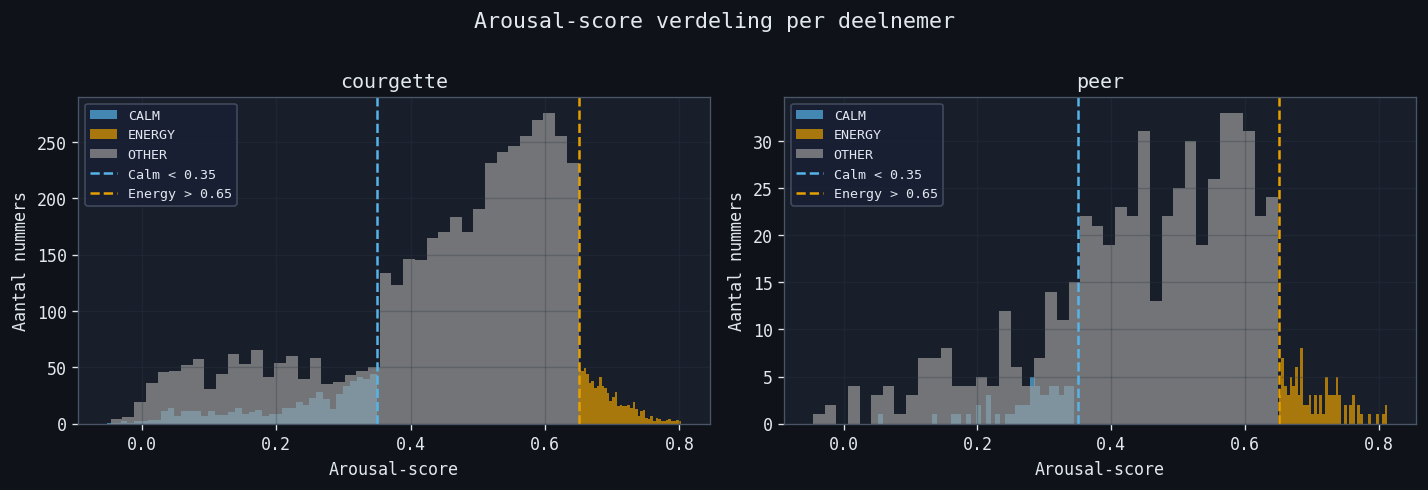

In [8]:
# ── 4c. Arousal-score distributie (histogram per deelnemer) ───────────────────
n_cols = min(2, len(results))
n_rows = (len(results) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)

for idx, (codename, (df_c, _, _)) in enumerate(results.items()):
    ax = axes[idx // n_cols][idx % n_cols]
    for cls in ["calm", "energy", "other"]:
        subset = df_c[df_c["class"] == cls]["arousal_score"]
        ax.hist(subset, bins=40, color=CLASS_COLORS[cls], alpha=0.7,
                label=cls.upper(), edgecolor="none")
    ax.axvline(CALM_THRESHOLD, color="#56b4e9", linestyle="--",
               linewidth=1.5, label=f"Calm < {CALM_THRESHOLD}")
    ax.axvline(ENERGY_THRESHOLD, color="#e69f00", linestyle="--",
               linewidth=1.5, label=f"Energy > {ENERGY_THRESHOLD}")
    ax.set_title(codename)
    ax.set_xlabel("Arousal-score")
    ax.set_ylabel("Aantal nummers")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Lege subplots verbergen
for idx in range(len(results), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle("Arousal-score verdeling per deelnemer", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# ── 4d. Drempelwaarde-gevoeligheidsanalyse ────────────────────────────────────
# Sweept calm- en energy-drempels om te zien hoe de klasseverdeling verschuift.
# Helpt bij het vinden van stabiele drempelgebieden.

calm_range   = np.arange(0.25, 0.46, 0.05)
energy_range = np.arange(0.55, 0.76, 0.05)

for codename, (df_c, df_scaled, _) in results.items():
    sweep_rows = []
    for ct in calm_range:
        for et in energy_range:
            if ct >= et:
                continue
            labels = [
                "calm"   if a < ct and v >= VALENCE_FLOOR else
                "energy" if a > et else "other"
                for a, v in zip(df_c["arousal_score"], df_scaled["valence"])
            ]
            n_total = len(labels)
            sweep_rows.append({
                "calm_thresh":   round(ct, 2),
                "energy_thresh": round(et, 2),
                "n_calm":        labels.count("calm"),
                "pct_calm":      round(labels.count("calm") / n_total * 100, 1),
                "n_energy":      labels.count("energy"),
                "pct_energy":    round(labels.count("energy") / n_total * 100, 1),
                "n_other":       labels.count("other"),
            })

    sweep_df = pd.DataFrame(sweep_rows)

    print(f"\n{codename} — drempelwaarde-sweep (gesorteerd op n_calm desc)")
    display(
        sweep_df.sort_values("n_calm", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    # Markeer huidige instellingen
    current = sweep_df[
        (sweep_df["calm_thresh"]   == round(CALM_THRESHOLD, 2)) &
        (sweep_df["energy_thresh"] == round(ENERGY_THRESHOLD, 2))
    ]
    if not current.empty:
        print(f"  → Huidige instellingen (calm={CALM_THRESHOLD}, energy={ENERGY_THRESHOLD}):")
        display(current.reset_index(drop=True))


courgette — drempelwaarde-sweep (gesorteerd op n_calm desc)


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.45,0.60,1158,20.2,1455,25.4,3107
1,0.45,0.75,1158,20.2,47,0.8,4515
2,0.45,0.70,1158,20.2,254,4.4,4308
3,0.45,0.65,1158,20.2,737,12.9,3825
4,0.45,0.55,1158,20.2,2211,38.7,2351
5,0.40,0.60,832,14.5,1455,25.4,3433
6,0.40,0.75,832,14.5,47,0.8,4841
7,0.40,0.55,832,14.5,2211,38.7,2677
8,0.40,0.65,832,14.5,737,12.9,4151
9,0.40,0.70,832,14.5,254,4.4,4634


  → Huidige instellingen (calm=0.35, energy=0.65):


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.35,0.65,566,9.9,737,12.9,4417



peer — drempelwaarde-sweep (gesorteerd op n_calm desc)


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.45,0.60,129,18.7,170,24.6,392
1,0.45,0.75,129,18.7,14,2.0,548
2,0.45,0.70,129,18.7,46,6.7,516
3,0.45,0.65,129,18.7,96,13.9,466
4,0.45,0.55,129,18.7,257,37.2,305
5,0.40,0.60,89,12.9,170,24.6,432
6,0.40,0.75,89,12.9,14,2.0,588
7,0.40,0.55,89,12.9,257,37.2,345
8,0.40,0.65,89,12.9,96,13.9,506
9,0.40,0.70,89,12.9,46,6.7,556


  → Huidige instellingen (calm=0.35, energy=0.65):


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.35,0.65,53,7.7,96,13.9,542


In [10]:
# ── 4e. Spot-check — 10 willekeurige nummers per klasse ──────────────────────
# Meest directe validatie: kloppen de nummers qua gevoel met hun klasse?

spot_cols_base = ["name", "artists", "tempo", "energy", "valence", "loudness", "arousal_score", "class"]

for codename, (df_c, _, _) in results.items():
    spot_cols = [c for c in spot_cols_base if c in df_c.columns]
    print(f"\n{'═'*70}")
    print(f"  {codename} — spot-check")
    print(f"{'═'*70}")
    for cls in ["calm", "energy", "other"]:
        subset = df_c[df_c["class"] == cls]
        n_show = min(10, len(subset))
        print(f"\n  {cls.upper()} ({n_show} van {len(subset)} nummers)")
        display(
            subset[spot_cols]
            .sample(n_show, random_state=RANDOM_STATE)
            .reset_index(drop=True)
        )


══════════════════════════════════════════════════════════════════════
  courgette — spot-check
══════════════════════════════════════════════════════════════════════

  CALM (10 van 566 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,If You Love Her,Forest Blakk,50.827,0.4450,0.278,-8.087,0.301001,calm
1,At Last,Etta James,87.430,0.3480,0.328,-8.631,0.310634,calm
2,Taste,Jonka Tribute,112.974,0.1100,0.459,-18.928,0.213832,calm
3,(You Make Me Feel Like) A Natural Woman,Aretha Franklin,110.890,0.2710,0.405,-10.083,0.324525,calm
4,Lopen Tot De Zon Komt,Acda en de Munnik,98.811,0.3280,0.356,-9.079,0.296804,calm
5,Sera,Carluccio,74.296,0.0895,0.289,-28.853,0.071816,calm
6,Woman,Denver Paige,114.648,0.0765,0.440,-23.549,0.178424,calm
7,Daar Gaat Ze,Clouseau,87.024,0.3330,0.637,-14.952,0.270419,calm
8,Perfect,Claire Haeving,85.843,0.0138,0.312,-22.508,0.094474,calm
9,Messy,Emma Lorents,94.999,0.0738,0.404,-28.523,0.121733,calm



  ENERGY (10 van 737 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,Mo Money (feat. Jadakiss),Justina Valentine;Jadakiss,174.915,0.746,0.2080,-6.844,0.674031,energy
1,Fight Song,Rachel Platten,175.924,0.714,0.3300,-4.987,0.677924,energy
2,Ocean Avenue,Yellowcard,173.734,0.904,0.7860,-3.751,0.746883,energy
3,Never Alone (feat. Lizzy Land),Odd Mob;Lizzy Land,133.999,0.930,0.2940,-4.362,0.683858,energy
4,Low Mode,GOOSE,119.963,0.876,0.6370,-3.483,0.650605,energy
5,I Like The Way - Radio Edit,Bodyrockers,127.981,0.856,0.7860,-3.629,0.654062,energy
6,Into Oblivion,Lamb of God,134.934,0.992,0.3150,-3.505,0.710584,energy
7,"Sugar, We're Goin Down",Fall Out Boy,162.011,0.842,0.5740,-4.784,0.699744,energy
8,Two Things,MIND,160.962,0.834,0.4390,-2.789,0.707872,energy
9,Time - Alan Walker Remix,Alan Walker;Hans Zimmer,127.967,0.941,0.0387,-7.908,0.656809,energy



  OTHER (10 van 4417 nummers)


...

,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,Over Jordan,Papa M,89.258,0.196,0.283,-15.491,0.165526,calm
1,Homesick,Dua Lipa,85.728,0.224,0.399,-8.683,0.215452,calm
2,When Will I Learn,Kina Grannis,129.650,0.278,0.374,-13.686,0.287989,calm
3,Jolene,Ray LaMontagne,119.656,0.142,0.288,-15.196,0.216724,calm
4,First Day Of My Life,Bright Eyes,95.345,0.201,0.385,-17.024,0.172010,calm
5,"Cello Suite No. 1 in G Major, BWV 1007: I. Pré...",Johann Sebastian Bach;Viviane Spanoghe,97.155,0.123,0.745,-26.413,0.050987,calm
6,Ho Hey,The Lumineers,79.907,0.471,0.421,-9.182,0.321989,calm
7,Liability,Lorde,76.715,0.218,0.345,-11.160,0.184774,calm
8,Ready or Not,Fugees;Ms. Lauryn Hill;Wyclef Jean;Pras,89.129,0.428,0.524,-13.392,0.334964,calm
9,No Right To Love You - Acoustic,Rhys Lewis,84.186,0.269,0.520,-10.600,0.227557,calm



  ENERGY (10 van 96 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,I Love It,Icona Pop;Charli xcx,125.953,0.901,0.860,-2.686,0.695573,energy
1,All at Once,The Fray,133.879,0.863,0.509,-2.509,0.685277,energy
2,Everything Is AWESOME!!! (feat. The Lonely Isl...,Tegan and Sara;The Lonely Island,147.999,0.960,0.738,-3.595,0.750909,energy
3,She Will Be Loved,Maroon 5,203.867,0.711,0.539,-5.494,0.738895,energy
4,Red Light Green Light,Used,171.958,0.809,0.359,-4.480,0.724593,energy
5,Meant to Be (feat. Florida Georgia Line),Bebe Rexha;Florida Georgia Line,154.084,0.783,0.579,-6.458,0.669103,energy
6,"Goodbye, Goodbye",Tegan and Sara,134.970,0.873,0.736,-5.581,0.676179,energy
7,Shut Up and Dance,WALK THE MOON,128.038,0.866,0.619,-3.804,0.670464,energy
8,That's Not My Name,The Ting Tings,145.042,0.901,0.959,-3.152,0.727453,energy
9,DARE (feat. Shaun Ryder & Roses Gabor),Gorillaz;Shaun Ryder;Roses Gabor,120.264,0.891,0.966,-5.852,0.656951,energy



  OTHER (10 van 542 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,You Wouldn't Like Me,The Beths,147.648,0.5720,0.6170,-8.114,0.564966,other
1,Pian Perduto,Olivia Belli;Louisa Fuller;John Metcalfe;Chris...,135.753,0.0268,0.0508,-24.540,0.096843,other
2,Ride,Lana Del Rey,93.763,0.6860,0.1890,-5.520,0.501914,other
3,Christine,Christine and the Queens,100.027,0.3640,0.4540,-10.322,0.377606,other
4,Secret - Acoustic,Angel Snow,112.580,0.2950,0.1450,-11.548,0.309071,other
5,Snowman,Sia,104.953,0.5240,0.3390,-6.222,0.449521,other
6,Escape,Hans Zimmer;Richard Harvey,143.778,0.3410,0.0403,-15.733,0.324043,other
7,Save Yourself,KALEO,120.436,0.3380,0.1110,-8.608,0.373359,other
8,Escape (The Pina Colada Song),Rupert Holmes,139.344,0.7390,0.9540,-7.198,0.610043,other
9,Bohemian Bird,Grizfolk,145.034,0.6370,0.1730,-8.081,0.575830,other


---
## 5. Opslaan

In [11]:
# ── 5a. classified_songs.csv per deelnemer ────────────────────────────────────
internal_cols = {"kmeans_cluster", "kmeans_label", "gmm_cluster", "gmm_label", "gmm_confidence"}

for codename, (df_c, _, _) in results.items():
    out_dir = ANALYSIS_DIR / codename
    out_dir.mkdir(parents=True, exist_ok=True)

    save_cols = [c for c in df_c.columns if c not in internal_cols]
    csv_path = out_dir / "classified_songs.csv"
    df_c[save_cols].to_csv(csv_path, index=False)
    print(f"  ✓ {codename}: {len(df_c)} nummers → {csv_path.relative_to(PROJECT_ROOT)}")

  ✓ courgette: 5720 nummers → data\analysis\courgette\classified_songs.csv
  ✓ peer: 691 nummers → data\analysis\peer\classified_songs.csv


In [12]:
# ── 5b. Config opslaan per deelnemer ─────────────────────────────────────────
# Scaler is al opgeslagen in classify_pipeline() (bij REUSE_MODEL=False).
# Hier slaan we de config op met drempelwaarden en klasseverdeling.

for codename, (df_c, _, _) in results.items():
    counts = df_c["class"].value_counts()
    config = {
        "created":             datetime.now().isoformat(),
        "participant":         codename,
        "n_songs_total":       len(frames[codename]),
        "n_songs_classified":  len(df_c),
        "scoring_features":    SCORING_FEATURES,
        "arousal_weights":     AROUSAL_WEIGHTS,
        "thresholds": {
            "calm":         CALM_THRESHOLD,
            "energy":       ENERGY_THRESHOLD,
            "valence_floor": VALENCE_FLOOR,
        },
        "pre_filters": {
            "speechiness_max": SPEECHINESS_MAX,
            "liveness_max":    LIVENESS_MAX,
        },
        "class_distribution": {
            cls: int(counts.get(cls, 0)) for cls in ["calm", "energy", "other"]
        },
    }
    config_path = MODELS_DIR / f"{codename}_config.json"
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)
    print(f"  ✓ {codename}: config → {config_path.name}")

print("\nKlaar.")

  ✓ courgette: config → courgette_config.json
  ✓ peer: config → peer_config.json

Klaar.
